In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()

2025-09-02 06:50:37.713121: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756795838.048942      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756795838.146047      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Using GPU
Num GPUs Available:  2


In [4]:
# disease_types = ['Cirrhosis','Fibrosis','No Fibrosis']
# disease_types = ['Cirrhosis','Periportal Fibrosis','Portal Fibrosis','Septal Fibrosis','No Fibrosis']
# disease_types = ['Benign','Malignant','Normal']

disease_types = ['Cirrhosis','Periportal Fibrosis','Portal Fibrosis','Septal Fibrosis','No Fibrosis']

data_dir = '/kaggle/input/aug-pinn/AUG_liver/Liver_Augmented_dataset_normal'

train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(data_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])
train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])

In [5]:
class FibrosisDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.dataframe.iloc[idx, 0])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.dataframe.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
dataset = FibrosisDataset(train, data_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet50 (without pretrained weights)
model = models.resnet50(pretrained=False)

# Replace classifier head (fc layer in ResNet)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(disease_types))

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last 10 parameter tensors
for param in list(model.parameters())[-10:]:
    param.requires_grad = True

model = model.to(device)

# Define loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [9]:
epochs = 50
train_losses, val_losses, val_accs = [], [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100 * correct / total)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%")


Epoch [1/50], Train Loss: 1.1316, Val Loss: 1.3121, Val Acc: 51.01%
Epoch [2/50], Train Loss: 0.8334, Val Loss: 0.8606, Val Acc: 62.56%
Epoch [3/50], Train Loss: 0.6932, Val Loss: 0.8060, Val Acc: 64.57%
Epoch [4/50], Train Loss: 0.5743, Val Loss: 0.7378, Val Acc: 68.27%
Epoch [5/50], Train Loss: 0.4794, Val Loss: 0.6276, Val Acc: 72.65%
Epoch [6/50], Train Loss: 0.4422, Val Loss: 0.7860, Val Acc: 67.49%
Epoch [7/50], Train Loss: 0.4042, Val Loss: 1.1668, Val Acc: 64.69%
Epoch [8/50], Train Loss: 0.3301, Val Loss: 0.5987, Val Acc: 74.55%
Epoch [9/50], Train Loss: 0.3154, Val Loss: 1.1367, Val Acc: 64.01%
Epoch [10/50], Train Loss: 0.2674, Val Loss: 0.8095, Val Acc: 72.98%
Epoch [11/50], Train Loss: 0.2154, Val Loss: 0.7171, Val Acc: 75.78%
Epoch [12/50], Train Loss: 0.1757, Val Loss: 0.7453, Val Acc: 75.67%
Epoch [13/50], Train Loss: 0.1888, Val Loss: 1.1435, Val Acc: 69.39%
Epoch [14/50], Train Loss: 0.1614, Val Loss: 0.7218, Val Acc: 74.89%
Epoch [15/50], Train Loss: 0.1105, Val Loss

In [10]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())


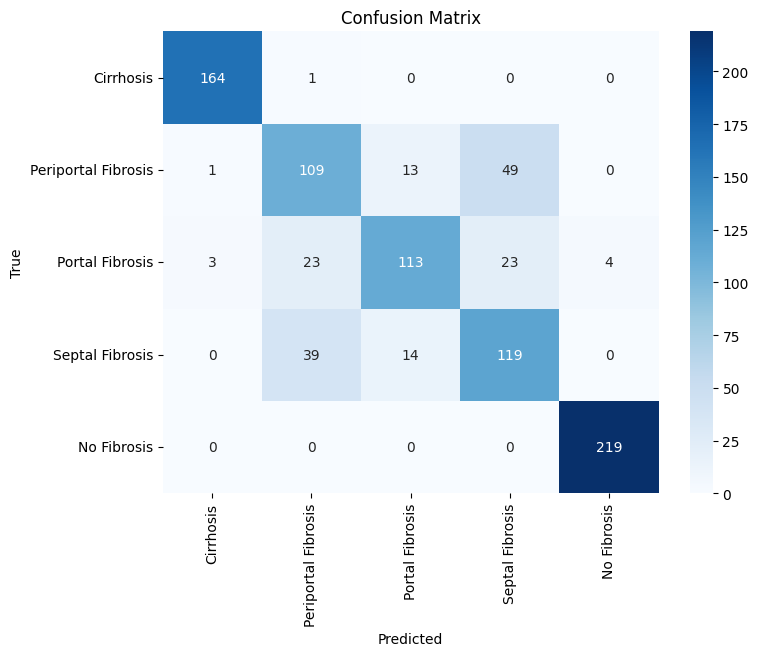

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=disease_types, yticklabels=disease_types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [12]:
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=disease_types))

Classification Report:
                      precision    recall  f1-score   support

          Cirrhosis       0.98      0.99      0.98       165
Periportal Fibrosis       0.63      0.63      0.63       172
    Portal Fibrosis       0.81      0.68      0.74       166
    Septal Fibrosis       0.62      0.69      0.66       172
        No Fibrosis       0.98      1.00      0.99       219

           accuracy                           0.81       894
          macro avg       0.80      0.80      0.80       894
       weighted avg       0.81      0.81      0.81       894



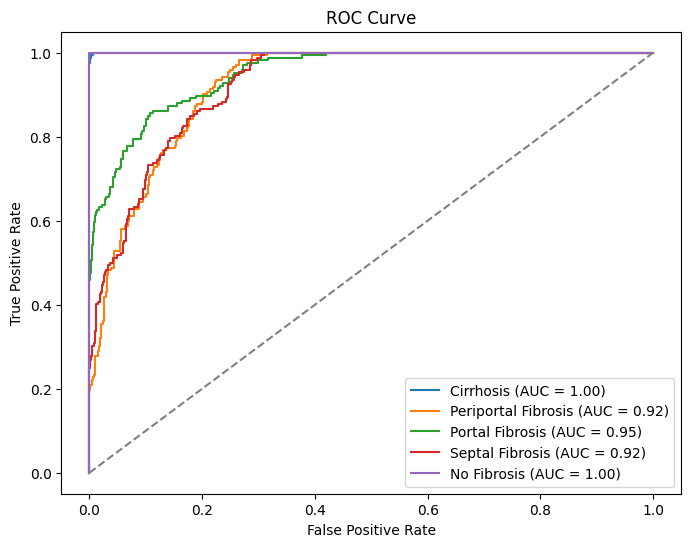

In [13]:
# ROC AUC
fpr, tpr, roc_auc = {}, {}, {}
y_true_onehot = np.eye(len(disease_types))[y_true]
y_prob = np.array(y_prob)

for i in range(len(disease_types)):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_true_onehot[:, i], y_prob[:, i])

plt.figure(figsize=(8,6))
for i in range(len(disease_types)):
    plt.plot(fpr[i], tpr[i], label=f"{disease_types[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

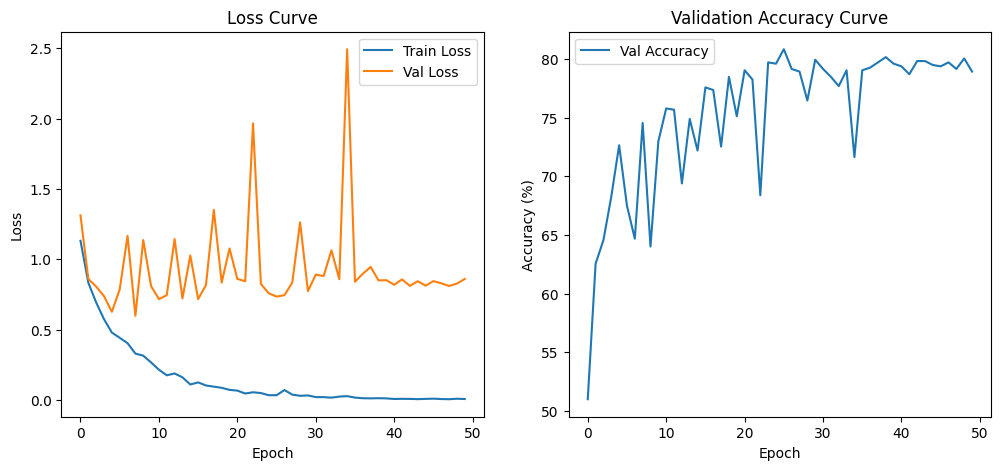

In [14]:
# Loss & Accuracy Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy Curve")
plt.legend()
plt.show()


In [15]:
torch.save(model, "/kaggle/working/vgg16_baseline_10_layer_trainable_twoclass.pth")